<a href="https://colab.research.google.com/github/shreeja-tangutur/DS4002-Project2/blob/main/DS4002Project2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Air Quality Data Analysis and Visualization

## Overview
This notebook performs exploratory data analysis and cleaning on NYC air quality data. It loads raw air quality measurements, explores geographic and temporal patterns, filters for specific pollutants and geographic areas, and creates visualizations.

## Key Operations
1. **Data Loading & Exploration**: Loads Air_Quality.csv and examines structure, columns, and basic statistics
2. **Data Cleaning**: Converts date columns to datetime format and sorts chronologically
3. **Exploratory Analysis**: Analyzes average pollutant levels by area, identifies top/bottom areas, and checks for duplicates
4. **Data Filtering**: Creates filtered datasets for:
   - PM2.5 (Fine particles) pollutant only
   - NYC Community Districts (CD) only
   - Combined CD + PM2.5 dataset
5. **Visualization**: Generates line plot of PM2.5 trends over time and bar chart of top 5 highest PM2.5 community districts

In [41]:
import pandas as pd

# Load data
df = pd.read_csv('../DATA/Air_Quality.csv')

# Basic overview
print("Shape of dataset:", df.shape)
print("\nColumn names:")
print(df.columns)

print("\nFirst 5 rows:")
display(df.head())

print("\nData types:")
print(df.dtypes)



Shape of dataset: (18862, 12)

Column names:
Index(['Unique ID', 'Indicator ID', 'Name', 'Measure', 'Measure Info',
       'Geo Type Name', 'Geo Join ID', 'Geo Place Name', 'Time Period',
       'Start_Date', 'Data Value', 'Message'],
      dtype='object')

First 5 rows:


,Unique ID,Indicator ID,Name,Measure,Measure Info,Geo Type Name,Geo Join ID,Geo Place Name,Time Period,Start_Date,Data Value,Message
0,336867,375,Nitrogen dioxide (NO2),Mean,ppb,CD,407,Flushing and Whitestone (CD7),Winter 2014-15,12/01/2014,23.97,NaN
1,336741,375,Nitrogen dioxide (NO2),Mean,ppb,CD,107,Upper West Side (CD7),Winter 2014-15,12/01/2014,27.42,NaN
2,550157,375,Nitrogen dioxide (NO2),Mean,ppb,CD,414,Rockaway and Broad Channel (CD14),Annual Average 2017,01/01/2017,12.55,NaN
3,412802,375,Nitrogen dioxide (NO2),Mean,ppb,CD,407,Flushing and Whitestone (CD7),Winter 2015-16,12/01/2015,22.63,NaN
4,412803,375,Nitrogen dioxide (NO2),Mean,ppb,CD,407,Flushing and Whitestone (CD7),Summer 2016,06/01/2016,14.00,NaN



Data types:
Unique ID           int64
Indicator ID        int64
Name               object
Measure            object
Measure Info       object
Geo Type Name      object
Geo Join ID         int64
Geo Place Name     object
Time Period        object
Start_Date         object
Data Value        float64
Message           float64
dtype: object


In [42]:
# Convert to datetime
df['Date'] = pd.to_datetime(df['Start_Date'])

# Sort ascending
df = df.sort_values(by='Date')

# Reset index
df = df.reset_index(drop=True)

# Save cleaned data
df.to_csv('../DATA/Air_Quality_Cleaned.csv', index=False)
print("Cleaned data saved to ../DATA/Air_Quality_Cleaned.csv")

print("Sorted by Date (Ascending):")
display(df.head())


Cleaned data saved to ../DATA/Air_Quality_Cleaned.csv
Sorted by Date (Ascending):


,Unique ID,Indicator ID,Name,Measure,Measure Info,Geo Type Name,Geo Join ID,Geo Place Name,Time Period,Start_Date,Data Value,Message,Date
0,131263,657,Asthma emergency department visits due to PM2.5,Estimated annual rate (age 18+),"per 100,000 adults",Borough,2,Brooklyn,2005-2007,01/01/2005,55.500000,NaN,2005-01-01
1,130380,639,Deaths due to PM2.5,Estimated annual rate (age 30+),"per 100,000 adults",UHF42,308,Greenwich Village - SoHo,2005-2007,01/01/2005,45.400000,NaN,2005-01-01
2,130390,639,Deaths due to PM2.5,Estimated annual rate (age 30+),"per 100,000 adults",UHF42,408,Jamaica,2005-2007,01/01/2005,58.200000,NaN,2005-01-01
3,154485,645,Annual vehicle miles traveled (trucks),Million miles,per square mile,CD,402,Woodside and Sunnyside (CD2),2005,01/01/2005,5.029655,NaN,2005-01-01
4,131062,653,Asthma emergency departments visits due to Ozone,Estimated annual rate (under age 18),"per 100,000 children",UHF42,408,Jamaica,2005-2007,01/01/2005,103.900000,NaN,2005-01-01


In [43]:
print("Earliest date:", df['Date'].min())
print("Latest date:", df['Date'].max())
print("Number of unique timestamps:", df['Date'].nunique())


Earliest date: 2005-01-01 00:00:00
Latest date: 2023-06-01 00:00:00
Number of unique timestamps: 46


In [44]:
# Identify unique areas

print("Unique Areas:")
areas = df['Geo Place Name'].unique()
print(areas)

print("\nNumber of Areas:", len(areas))



Unique Areas:
['Brooklyn' 'Greenwich Village - SoHo' 'Jamaica'
 'Woodside and Sunnyside (CD2)' 'Sheepshead Bay (CD15)'
 'Hunts Point - Mott Haven' 'Queens Village (CD13)'
 'High Bridge - Morrisania' 'Gramercy Park - Murray Hill'
 'Canarsie - Flatlands' 'East Flatbush - Flatbush' 'Flushing - Clearview'
 'Willowbrook' 'Sunset Park' 'Bronx' 'Coney Island - Sheepshead Bay'
 'Williamsburg - Bushwick' 'Chelsea - Clinton' 'Upper West Side'
 'Pelham - Throgs Neck' 'Staten Island' 'Bayside - Little Neck'
 'Rockaways' 'Northeast Bronx' 'Upper East Side' 'Crotona -Tremont'
 'Bedford Stuyvesant - Crown Heights' 'Ridgewood - Forest Hills'
 'Downtown - Heights - Slope' 'Central Harlem - Morningside Heights'
 'Kingsbridge - Riverdale' 'Long Island City - Astoria'
 'Washington Heights' 'Manhattan' 'Fordham - Bronx Pk' 'Borough Park'
 'Throgs Neck and Co-op City (CD10)' 'Greenpoint' 'Port Richmond'
 'East New York' 'Midtown (CD5)' 'Ridgewood and Maspeth (CD5)'
 'South Beach - Tottenville' 'Bensonhurst 

In [45]:
avg_area_pollutant = (
    df.groupby(['Geo Place Name', 'Name'])['Data Value']
      .mean()
      .reset_index()
)
# Looking at the pollutant measure

print("Average Air Quality per Area and Pollutant:")
display(avg_area_pollutant)

Average Air Quality per Area and Pollutant:


,Geo Place Name,Name,Data Value
0,Bay Ridge and Dyker Heights (CD10),Annual vehicle miles traveled,70.910190
1,Bay Ridge and Dyker Heights (CD10),Annual vehicle miles traveled (cars),65.642592
2,Bay Ridge and Dyker Heights (CD10),Annual vehicle miles traveled (trucks),3.983465
3,Bay Ridge and Dyker Heights (CD10),Fine particles (PM 2.5),8.530959
4,Bay Ridge and Dyker Heights (CD10),Nitrogen dioxide (NO2),19.247917
...,...,...,...
1352,Woodside and Sunnyside (CD2),Fine particles (PM 2.5),9.980413
1353,Woodside and Sunnyside (CD2),Nitrogen dioxide (NO2),21.983543
1354,Woodside and Sunnyside (CD2),Outdoor Air Toxics - Benzene,1.834309
1355,Woodside and Sunnyside (CD2),Outdoor Air Toxics - Formaldehyde,2.400000


In [46]:
area_avg = (
    avg_area_pollutant
    .groupby('Geo Place Name')['Data Value']
    .mean()
    .reset_index()
)



area_avg_sorted = area_avg.sort_values(by='Data Value', ascending=False)


# table that displays the top 3 areas with the highest average air quality values and the top 3 areas with the lowest average air quality values.
top3 = area_avg_sorted.head(3)
print("Top 3 Highest Average Air Quality Values:")
display(top3)
bottom3 = area_avg_sorted.tail(3)
print("Top 3 Lowest Average Air Quality Values:")
display(bottom3)



Top 3 Highest Average Air Quality Values:


,Geo Place Name,Data Value
95,Stuyvesant Town and Turtle Bay (CD6),53.621603
28,East Harlem,51.676142
42,Gramercy Park - Murray Hill,50.751755


Top 3 Lowest Average Air Quality Values:


,Geo Place Name,Data Value
84,South Beach - Tottenville,11.519418
81,Rockaway and Broad Channel (CD14),11.222026
99,Tottenville and Great Kills (CD3),10.288473


In [47]:
duplicate_area_date = (
    df.groupby(['Geo Place Name', 'Date'])
      .size()
      .reset_index(name='count')
)

# Keep only cases where count > 1
duplicates = duplicate_area_date[duplicate_area_date['count'] > 1]

print("Area-Date combinations with multiple entries:")
display(duplicates.head())

print("Total such cases:", len(duplicates))


Area-Date combinations with multiple entries:


,Geo Place Name,Date,count
0,Bay Ridge and Dyker Heights (CD10),2005-01-01,3
1,Bay Ridge and Dyker Heights (CD10),2008-12-01,4
2,Bay Ridge and Dyker Heights (CD10),2009-06-01,3
3,Bay Ridge and Dyker Heights (CD10),2009-12-01,4
4,Bay Ridge and Dyker Heights (CD10),2010-01-01,3


Total such cases: 4959


In [48]:
pm25_df = df[df['Name'] == 'Fine particles (PM 2.5)'].copy()

print("Filtered dataset shape:", pm25_df.shape)
display(pm25_df.head())


Filtered dataset shape: (6345, 13)


,Unique ID,Indicator ID,Name,Measure,Measure Info,Geo Type Name,Geo Join ID,Geo Place Name,Time Period,Start_Date,Data Value,Message,Date
897,168434,365,Fine particles (PM 2.5),Mean,mcg/m3,CD,317,East Flatbush (CD17),Winter 2008-09,12/01/2008,13.25,NaN,2008-12-01
898,177178,365,Fine particles (PM 2.5),Mean,mcg/m3,UHF42,502,Stapleton - St. George,Winter 2008-09,12/01/2008,11.46,NaN,2008-12-01
899,174115,365,Fine particles (PM 2.5),Mean,mcg/m3,UHF34,203,Bedford Stuyvesant - Crown Heights,Annual Average 2009,12/01/2008,10.75,NaN,2008-12-01
901,170179,365,Fine particles (PM 2.5),Mean,mcg/m3,CD,204,Highbridge and Concourse (CD4),Annual Average 2009,12/01/2008,11.96,NaN,2008-12-01
902,173109,365,Fine particles (PM 2.5),Mean,mcg/m3,UHF34,402,West Queens,Winter 2008-09,12/01/2008,13.50,NaN,2008-12-01


In [49]:
cd_df = df[df['Geo Type Name'] == 'CD'].copy()

# Filtered Data
print("Filtered dataset shape:", cd_df.shape)
display(cd_df.head())


Filtered dataset shape: (6844, 13)


,Unique ID,Indicator ID,Name,Measure,Measure Info,Geo Type Name,Geo Join ID,Geo Place Name,Time Period,Start_Date,Data Value,Message,Date
3,154485,645,Annual vehicle miles traveled (trucks),Million miles,per square mile,CD,402,Woodside and Sunnyside (CD2),2005,01/01/2005,5.029655,NaN,2005-01-01
6,154598,643,Annual vehicle miles traveled,Million miles,per square mile,CD,315,Sheepshead Bay (CD15),2005,01/01/2005,42.865708,NaN,2005-01-01
8,154614,643,Annual vehicle miles traveled,Million miles,per square mile,CD,413,Queens Village (CD13),2005,01/01/2005,59.429215,NaN,2005-01-01
47,154463,645,Annual vehicle miles traveled (trucks),Million miles,per square mile,CD,210,Throgs Neck and Co-op City (CD10),2005,01/01/2005,4.939819,NaN,2005-01-01
67,154446,645,Annual vehicle miles traveled (trucks),Million miles,per square mile,CD,105,Midtown (CD5),2005,01/01/2005,10.903427,NaN,2005-01-01


In [50]:
print(cd_df['Geo Type Name'].unique())

num_unique_cds = cd_df['Geo Place Name'].nunique()
# Unique CDs
print("Number of unique CDs:", num_unique_cds)



['CD']
Number of unique CDs: 59


In [51]:
cd_pm25_df = df[
    (df['Geo Type Name'] == 'CD') &
    (df['Name'] == 'Fine particles (PM 2.5)')
].copy()

print("Filtered shape:", cd_pm25_df.shape)
display(cd_pm25_df.head())

Filtered shape: (2655, 13)


,Unique ID,Indicator ID,Name,Measure,Measure Info,Geo Type Name,Geo Join ID,Geo Place Name,Time Period,Start_Date,Data Value,Message,Date
897,168434,365,Fine particles (PM 2.5),Mean,mcg/m3,CD,317,East Flatbush (CD17),Winter 2008-09,12/01/2008,13.25,NaN,2008-12-01
901,170179,365,Fine particles (PM 2.5),Mean,mcg/m3,CD,204,Highbridge and Concourse (CD4),Annual Average 2009,12/01/2008,11.96,NaN,2008-12-01
905,168450,365,Fine particles (PM 2.5),Mean,mcg/m3,CD,501,St. George and Stapleton (CD1),Winter 2008-09,12/01/2008,12.09,NaN,2008-12-01
907,168451,365,Fine particles (PM 2.5),Mean,mcg/m3,CD,502,South Beach and Willowbrook (CD2),Winter 2008-09,12/01/2008,11.77,NaN,2008-12-01
908,168395,365,Fine particles (PM 2.5),Mean,mcg/m3,CD,102,Greenwich Village and Soho (CD2),Winter 2008-09,12/01/2008,15.21,NaN,2008-12-01


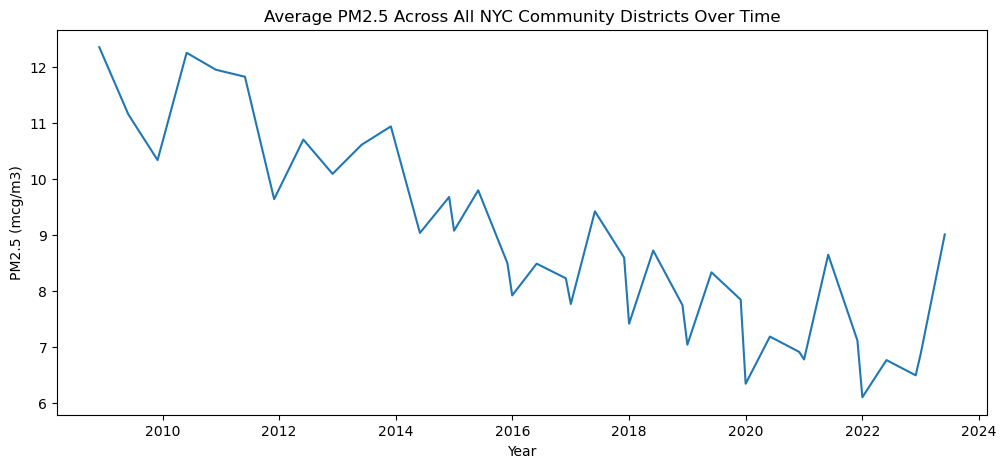

In [52]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Visualization 1 for overall PM2.5 trend over time across all CDs

overall_trend = (
    cd_pm25_df
    .groupby('Date')['Data Value']
    .mean()
    .reset_index()
)

plt.figure(figsize=(12,5))
plt.plot(overall_trend['Date'], overall_trend['Data Value'])
plt.title("Average PM2.5 Across All NYC Community Districts Over Time")
plt.xlabel("Year")
plt.ylabel("PM2.5 (mcg/m3)")
plt.savefig('../OUTPUT/pm25_trend.png', dpi=300, bbox_inches='tight')
plt.show()

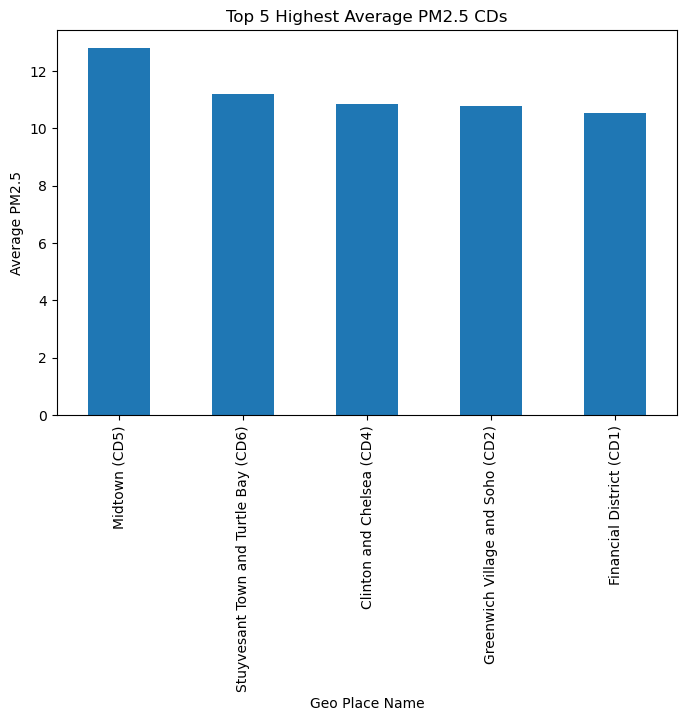

In [53]:
# Visualization 2 for top 5 CDs with highest average PM2.5 levels
cd_avg = (
    cd_pm25_df
    .groupby('Geo Place Name')['Data Value']
    .mean()
    .sort_values(ascending=False)
)

top5 = cd_avg.head(5)

plt.figure(figsize=(8,5))
top5.plot(kind='bar')
plt.title("Top 5 Highest Average PM2.5 CDs")
plt.ylabel("Average PM2.5")
plt.savefig('../OUTPUT/top5_pm25.png', dpi=300, bbox_inches='tight')
plt.show()